In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sgd

import func

In [3]:
device = "cuda:1"

def align(u,v):
	return np.sum(u*v)/np.sqrt(np.sum(u**2)*np.sum(v**2))

def ortho_mat(k, d):
    A = np.random.randn(d, k)
    Q, _ = np.linalg.qr(A)
    return Q.T

In [96]:
d = 60
gamma = 0.5
alpha = 5
k = int(gamma*d)
n = int(alpha*d**2)  

Delta = 0.0
# sig = lambda x: torch.tanh(2*x)
sig = lambda x: torch.relu(x)


v_np = np.linspace(3, 1, k)
# v_np = np.array([1/(p**1) for p in range(1, k+1)])
# v_np = np.ones(k)


v_np /= np.linalg.norm(v_np)
v0 = torch.tensor(v_np, dtype=torch.float32, device=device)

# mmse, qw = func.solve(n, d, Delta, v_np, g, m_e)
# kc = np.argmin(qw>0)
# kc, mmse

In [97]:
eta = 0.003 # learning rate
n_epoch = 10000
n_batch = 3
n_test = 10000



In [98]:
W0 = torch.from_numpy(ortho_mat(k, d).T).float().to(device)
X_train = torch.randn(n, d, device=device)
X_test  = torch.randn(n_test, d, device=device)

with torch.no_grad():
    Y_train = sig(X_train @ W0) @ v0 + torch.randn(n, device=device)*Delta**(.5)
    Y_test  = sig(X_test  @ W0) @ v0 


# v_init = v0
v_init = torch.full((k,), k**-.5, device=device)

# widths = [200, 150, 100, 50, 20, 15, 10, 8, 6, 4]
widths = [k]
Es_train = []
Es_test = []
Wfs = []
vfs = []
for width in widths:
    v_init = torch.full((width,), width**-.5, device=device)
    E_train, E_test, Wf, vf = sgd.train2(d, v_init[:width], n, sig, n_batch, n_epoch, eta, X_train, Y_train, X_test, Y_test, normalize=True)
    Es_train.append(E_train)
    Es_test.append(E_test)
    Wfs.append(Wf)
    vfs.append(vf)

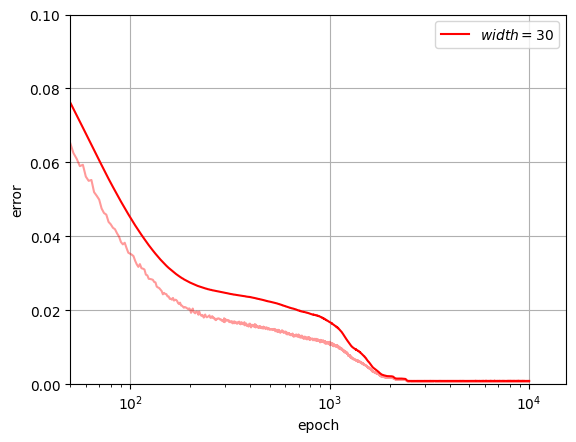

In [99]:
# colors = ['black', 'red', 'blue']
colors = ['red']

interval=2
epochs = range(0, n_epoch, interval)

for i in range(len(widths)):
    # plt.plot(epochs, Es_train[i][::interval], color=colors[i], linestyle='dotted')
    plt.plot(epochs, Es_train[i][::interval], color=colors[i], alpha=0.4)
    plt.plot(epochs, Es_test[i][::interval], color=colors[i], label=fr'$width = {widths[i]}$')

plt.ylim(0, 0.1)
plt.legend()
plt.xscale('log')
plt.xlabel('epoch')
plt.ylabel('error')
plt.xlim(50,)
plt.grid()
plt.legend()
# plt.savefig('smaller_width.pdf')
plt.show()


In [102]:
ind = 0
vf = vfs[ind]
Wf = Wfs[ind]

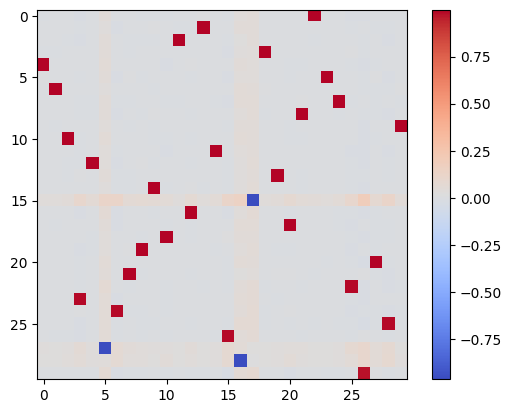

In [103]:
W0_ = np.array(W0.cpu()).T
Q = W0_@np.array(Wf).T
plt.imshow(Q, cmap='coolwarm')
plt.colorbar()
plt.show()


30


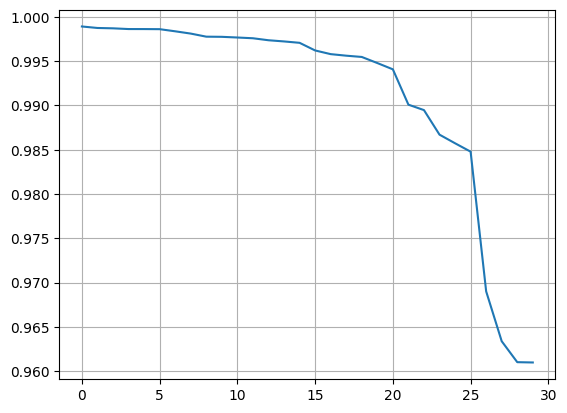

In [106]:
kc_sgd = 0 # number of learnable features by sgd
qs_sgd = []
for i in range(k):
    q_max = np.max(np.abs(Q[i]))
    if q_max > 0.9:
        kc_sgd += 1
        qs_sgd.append(q_max)

v0_np = v0.cpu().numpy()
vc_sgd = v0_np[kc_sgd-1]
qs_sgd = np.sort(qs_sgd)[::-1]

plt.plot(qs_sgd)

# plt.scatter(vf[:kc_sgd], qs_sgd)
print(kc_sgd)

plt.grid()
plt.show()